In [1]:
# Imports
import os
import sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import joblib
from xgboost import XGBRegressor
from tensorflow.keras.models import load_model
from tensorflow.keras.losses import MeanSquaredError

I0000 00:00:1785584589.486591  127193 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Global plot style
matplotlib.rcParams.update({
    'font.family': 'DejaVu Serif',
    'font.size': 16,
    'axes.labelweight': 'medium',
    'xtick.labelsize': 14,
    'ytick.labelsize': 14
})

In [3]:
# Paths and output directory
DATA_PATH = "1_data/processed/zone_sequence_merged.csv"
SAVE_DIR = "plots/results"
os.makedirs(SAVE_DIR, exist_ok=True)

In [4]:
# Zone-level results
models = ["Linear Reg.", "GPR", "XGBoost", "LSTM", "Transformer"]
zone_labels = [f"Zone {z}" for z in range(1, 9)]

results = {
    "RMSE": {
        "Linear Reg.":  [0.93, 1.01, 0.80, 0.57, 0.52, 0.77, 0.86, 0.64],
        "GPR":          [1.01, 0.94, 1.05, 0.72, 0.57, 0.84, 0.91, 0.70],
        "XGBoost":      [0.98, 0.95, 0.77, 0.53, 0.51, 0.76, 0.80, 0.67],
        "LSTM":         [1.00, 0.97, 0.86, 0.62, 0.53, 0.78, 0.91, 0.66],
        "Transformer":  [1.06, 1.02, 0.89, 0.62, 0.53, 0.75, 0.88, 0.66],
    },
    "MAE": {
        "Linear Reg.":  [0.48, 0.49, 0.30, 0.21, 0.22, 0.38, 0.40, 0.27],
        "GPR":          [0.54, 0.47, 0.38, 0.24, 0.23, 0.46, 0.40, 0.29],
        "XGBoost":      [0.48, 0.43, 0.29, 0.18, 0.21, 0.36, 0.36, 0.28],
        "LSTM":         [0.49, 0.44, 0.31, 0.21, 0.22, 0.36, 0.40, 0.26],
        "Transformer":  [0.53, 0.52, 0.32, 0.21, 0.22, 0.38, 0.41, 0.25],
    },
    "MR": {
        "Linear Reg.":  [0.00, -0.02,  0.07,  0.02,  0.06,  0.00,  0.07,  0.05],
        "GPR":          [0.01, -0.06,  0.31,  0.15,  0.12, -0.06,  0.14,  0.15],
        "XGBoost":      [0.08,  0.01,  0.12,  0.06,  0.06, -0.00,  0.07,  0.05],
        "LSTM":         [0.08,  0.09,  0.16,  0.12,  0.11,  0.17,  0.17,  0.10],
        "Transformer":  [0.07,  0.01,  0.19,  0.11,  0.08,  0.00,  0.16,  0.18],
    },
    "R2": {
        "Linear Reg.":  [0.426, 0.415, 0.584, 0.427, 0.222, 0.320, 0.502, 0.178],
        "GPR":          [0.329, 0.490, 0.278, 0.091, 0.050, 0.194, 0.441, 0.040],
        "XGBoost":      [0.363, 0.484, 0.611, 0.500, 0.234, 0.327, 0.563, 0.105],
        "LSTM":         [0.348, 0.474, 0.537, 0.346, 0.215, 0.332, 0.464, 0.153],
        "Transformer":  [0.272, 0.410, 0.500, 0.334, 0.233, 0.365, 0.503, 0.141],
    },
    "EMR": {
        "Linear Reg.":  [64.68, 68.17, 81.11, 83.78, 80.29, 69.82, 70.64, 78.44],
        "GPR":          [62.22, 67.35, 80.29, 84.60, 80.29, 62.63, 71.87, 78.85],
        "XGBoost":      [67.56, 72.28, 80.90, 86.04, 81.31, 72.48, 74.33, 78.85],
        "LSTM":         [67.71, 71.89, 81.58, 85.34, 81.05, 72.96, 72.38, 80.38],
        "Transformer":  [65.68, 63.52, 81.22, 84.87, 80.61, 68.79, 69.85, 82.09],
    },
}

# Metric display titles
metric_titles = {
    "RMSE": "RMSE [fires/day]",
    "MAE":  "MAE [fires/day]",
    "MR":   "MR [fires/day]",
    "R2":   "R² [-]",
    "EMR":  "EMR [-]",
}
metric_order = ["RMSE", "MAE", "MR", "R2", "EMR"]

# Zone color palette 
zone_colors = [
    "#C9A227",  
    "#7FB9E0",  
    "#1B7F5C",  
    "#E8D44D",  
    "#1F4E96", 
    "#C8642A",  
    "#D98AA8",  
    "#000000",  
]

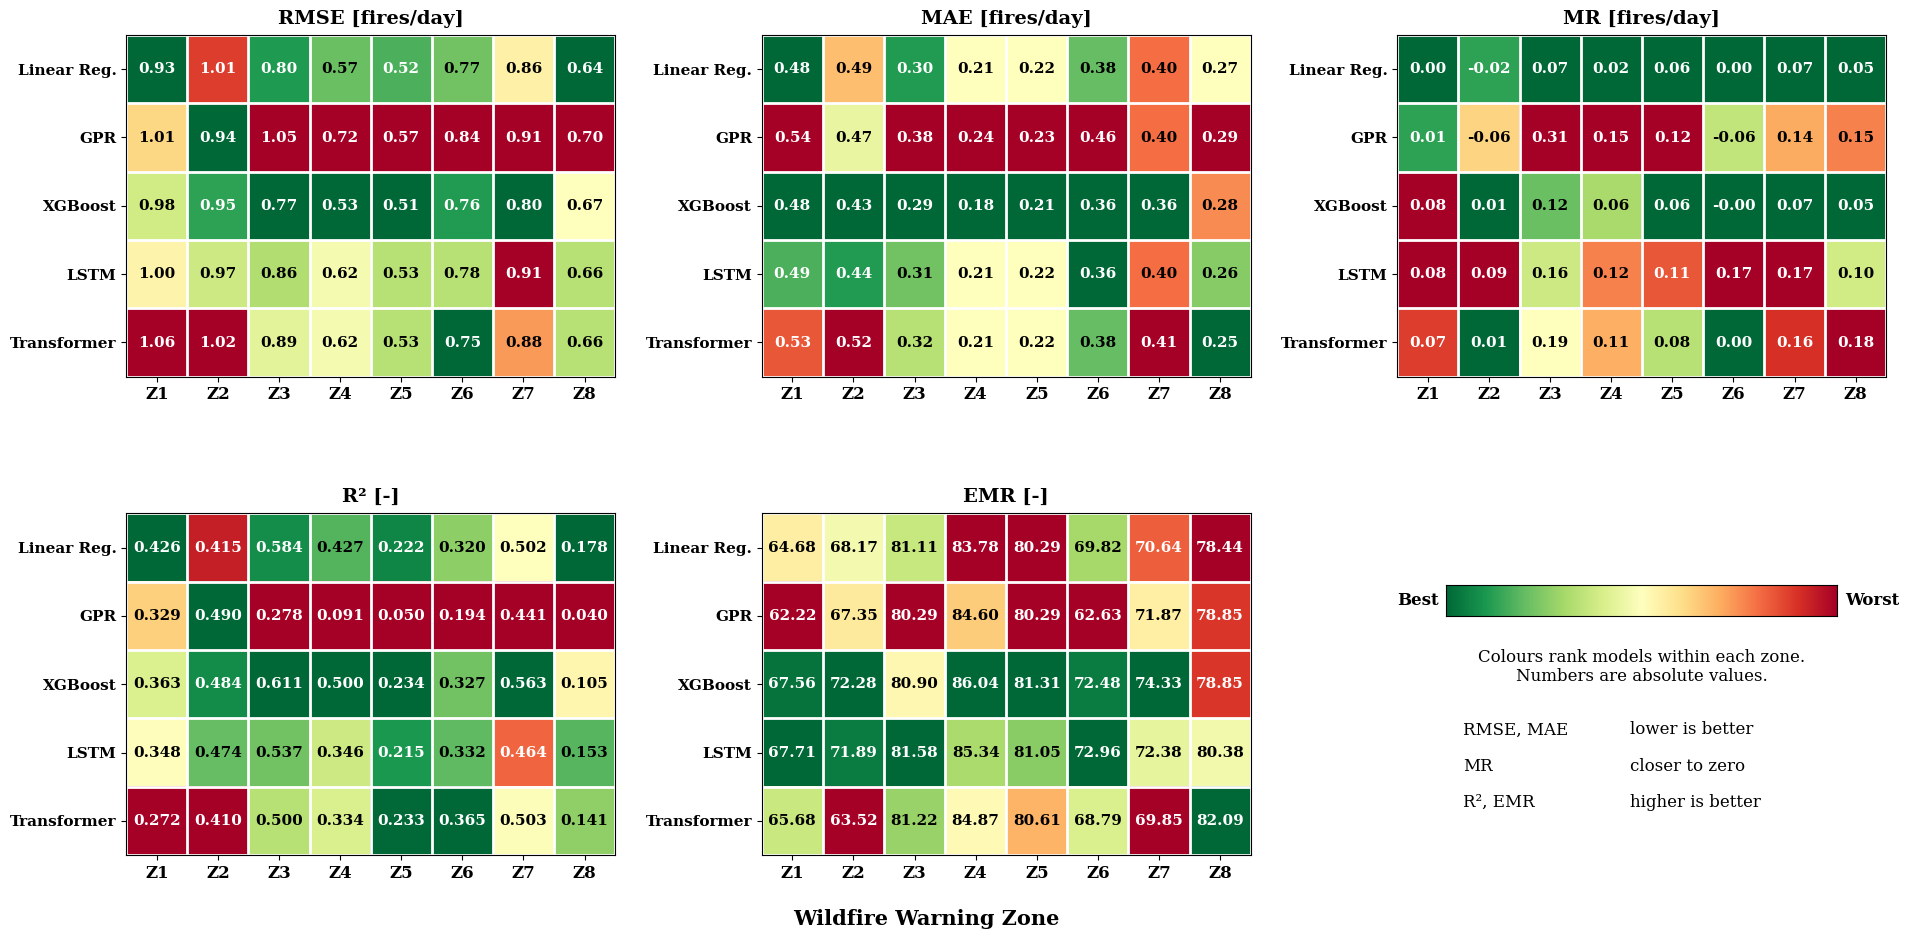

In [11]:
# %%
# Zone-level model comparison: heatmaps (one panel per metric)
import matplotlib.colors as mcolors

# Direction of "good" for each metric
metric_better = {
    "RMSE": "low",
    "MAE":  "low",
    "MR":   "zero",   # closer to zero = less bias
    "R2":   "high",
    "EMR":  "high",
}

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for ax_idx, metric in enumerate(metric_order):
    ax = axes[ax_idx]
    data = np.array([results[metric][m] for m in models])   # rows = models, cols = zones

    # Normalise within each zone (column): colour shows model rank in that zone
    shade = np.abs(data) if metric_better[metric] == "zero" else data
    col_min = shade.min(axis=0, keepdims=True)
    col_max = shade.max(axis=0, keepdims=True)
    scaled = (shade - col_min) / np.where(col_max - col_min == 0, 1, col_max - col_min)

    cmap = "RdYlGn" if metric_better[metric] == "high" else "RdYlGn_r"
    ax.imshow(scaled, cmap=cmap, vmin=0, vmax=1, aspect="auto")

    fmt = "{:.2f}" if metric != "R2" else "{:.3f}"
    rgba = plt.get_cmap(cmap)(scaled)
    for i in range(len(models)):
        for j in range(len(zone_labels)):
            r, g, b = rgba[i, j, :3]
            lum = 0.299 * r + 0.587 * g + 0.114 * b
            ax.text(j, i, fmt.format(data[i, j]), ha="center", va="center",
                    fontsize=11, fontweight="bold",
                    color="white" if lum < 0.55 else "black")

    ax.set_title(metric_titles[metric], fontsize=14, fontweight="bold", pad=8)
    ax.set_xticks(np.arange(len(zone_labels)))
    ax.set_xticklabels([f"Z{z}" for z in range(1, 9)], fontsize=12, fontweight="bold")
    ax.set_yticks(np.arange(len(models)))
    ax.set_yticklabels(models, fontsize=11, fontweight="bold",
                       ha="right", rotation_mode="anchor")
    ax.set_xticks(np.arange(-0.5, len(zone_labels), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(models), 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=2)
    ax.tick_params(which="minor", length=0)

# Legend panel: colour bar + metric direction table
axes[5].axis("off")

gradient = np.linspace(0, 1, 256).reshape(1, -1)
cbar_ax = axes[5].inset_axes([0.10, 0.70, 0.80, 0.09])
cbar_ax.imshow(gradient, cmap="RdYlGn_r", aspect="auto")
cbar_ax.set_xticks([])
cbar_ax.set_yticks([])
cbar_ax.text(-0.02, 0.5, "Best", transform=cbar_ax.transAxes,
             ha="right", va="center", fontsize=12, fontweight="bold")
cbar_ax.text(1.02, 0.5, "Worst", transform=cbar_ax.transAxes,
             ha="left", va="center", fontsize=12, fontweight="bold")

axes[5].text(0.5, 0.55, "Colours rank models within each zone.\nNumbers are absolute values.",
             ha="center", va="center", fontsize=12)

# Invisible two-column table so the metric directions align
tbl = axes[5].table(
    cellText=[["RMSE, MAE", "lower is better"],
              ["MR", "closer to zero"],
              ["R², EMR", "higher is better"]],
    cellLoc="left",
    colWidths=[0.34, 0.42],
    bbox=[0.12, 0.10, 0.76, 0.32],
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(12)
for cell in tbl.get_celld().values():
    cell.set_linewidth(0)
    cell.set_facecolor("none")
    cell.PAD = 0.04

fig.text(0.5, 0.03, "Wildfire Warning Zone", ha="center", fontsize=15, fontweight="bold")
plt.subplots_adjust(left=0.10, bottom=0.10, right=0.98, top=0.92, wspace=0.30, hspace=0.40)
plt.savefig(os.path.join(SAVE_DIR, "zone_result_heatmap.png"), dpi=600, bbox_inches="tight")

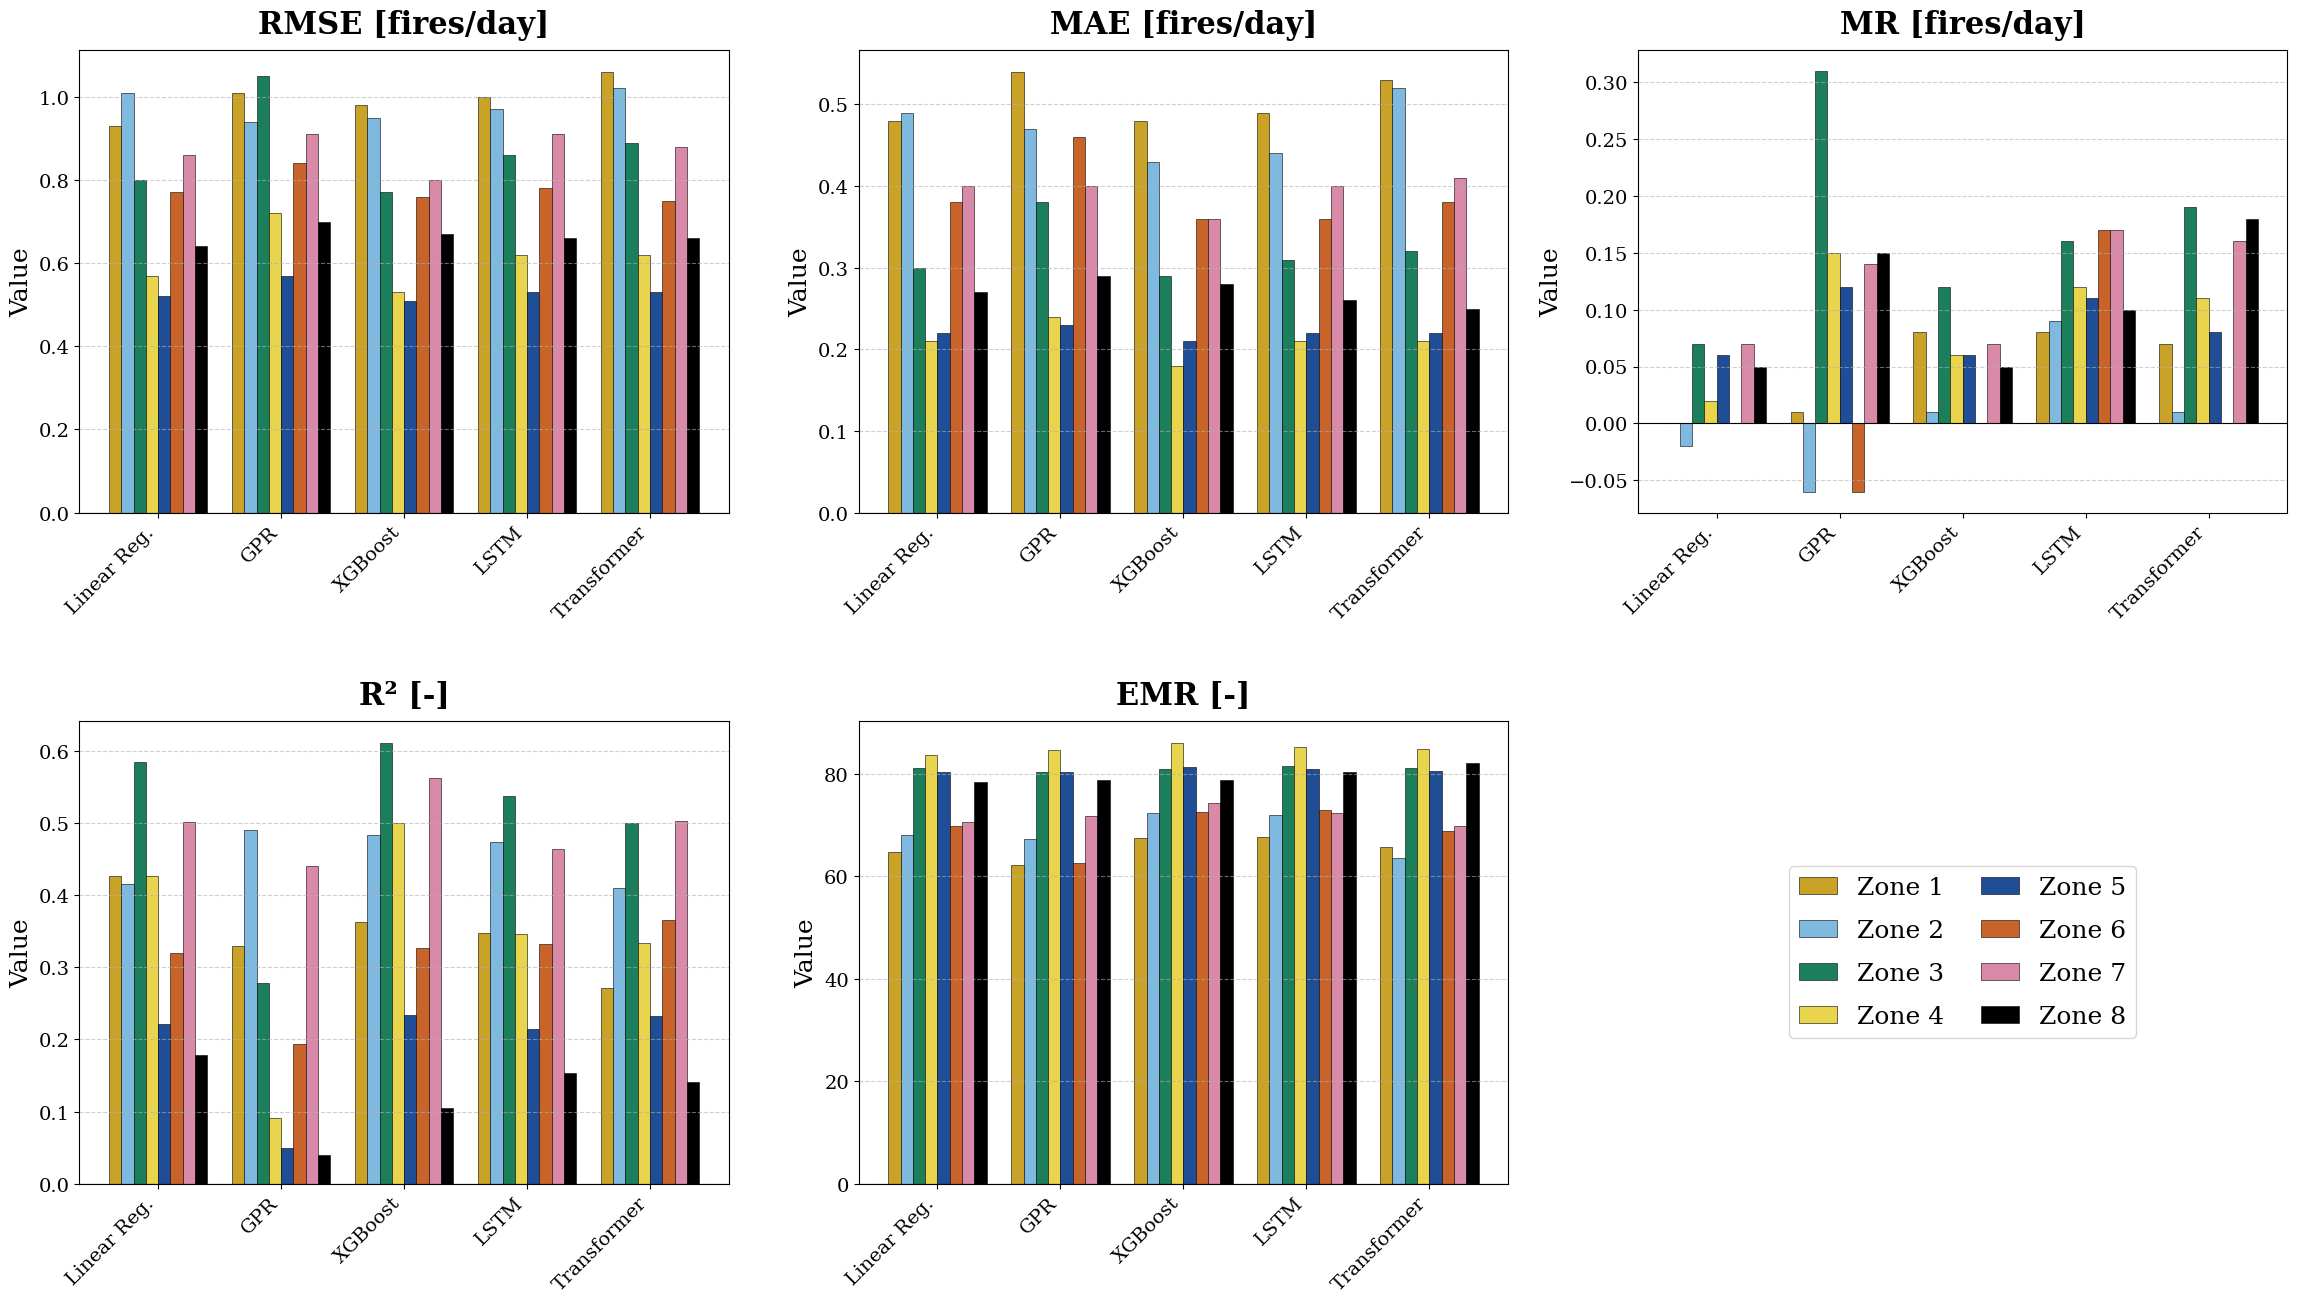

In [ ]:
# Zone-level model comparison: grouped bar charts (3 cols x 2 rows)
n_models = len(models)
n_zones = len(zone_labels)
x = np.arange(n_models)
bar_w = 0.10  

fig, axes = plt.subplots(2, 3, figsize=(24, 14))
axes = axes.flatten()

for ax_idx, metric in enumerate(metric_order):
    ax = axes[ax_idx]
    data = np.array([results[metric][m] for m in models]) 

    for z in range(n_zones):
        offsets = x + (z - (n_zones - 1) / 2) * bar_w
        ax.bar(offsets, data[:, z], width=bar_w,
               color=zone_colors[z], edgecolor="black", linewidth=0.4,
               label=zone_labels[z])

    ax.set_title(metric_titles[metric], fontsize=22, fontweight='bold', pad=12)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=45, ha="right", fontsize=14)
    ax.set_ylabel("Value", fontsize=18, fontweight='medium')
    ax.grid(axis="y", linestyle="--", alpha=0.6)
    ax.axhline(0, color="black", linewidth=0.8)  

# Use the 6th panel for the shared legend
axes[5].axis("off")
handles, labels = axes[0].get_legend_handles_labels()
axes[5].legend(handles, labels, ncol=2, loc="center", fontsize=18,
               frameon=True, title=None, handlelength=1.5,
               columnspacing=1.5, labelspacing=0.8)

plt.subplots_adjust(left=0.06, bottom=0.12, right=0.98, top=0.93,
                    wspace=0.20, hspace=0.45)
plt.savefig(os.path.join(SAVE_DIR, "zone_result_histogram.png"),
            dpi=600, bbox_inches="tight")

In [7]:
# Average zone-level performance: radar plot
avg_models = ["Linear Reg.", "GPR", "XGBoost", "LSTM", "Transformer"]

# Averages across the 8 zones
avg_results = {
    "RMSE": [0.762, 0.842, 0.746, 0.791, 0.801],
    "MAE":  [0.344, 0.376, 0.324, 0.336, 0.355],
    "MR":   [0.031, 0.095, 0.056, 0.125, 0.100],
    "R2":   [0.384, 0.239, 0.398, 0.359, 0.345],
    "EMR":  [0.746, 0.735, 0.767, 0.767, 0.746],
}

metric_styles = {
    "RMSE": {"label": "RMSE", "color": "#E8000B"},
    "MAE":  {"label": "MAE",  "color": "#F28E8E"},
    "MR":   {"label": "MR",   "color": "#1F6FB4"},
    "R2":   {"label": "R²",   "color": "#2CA02C"},
    "EMR":  {"label": "EMR",  "color": "#8E44AD"},
}
metric_plot_order = ["RMSE", "MAE", "MR", "R2", "EMR"]

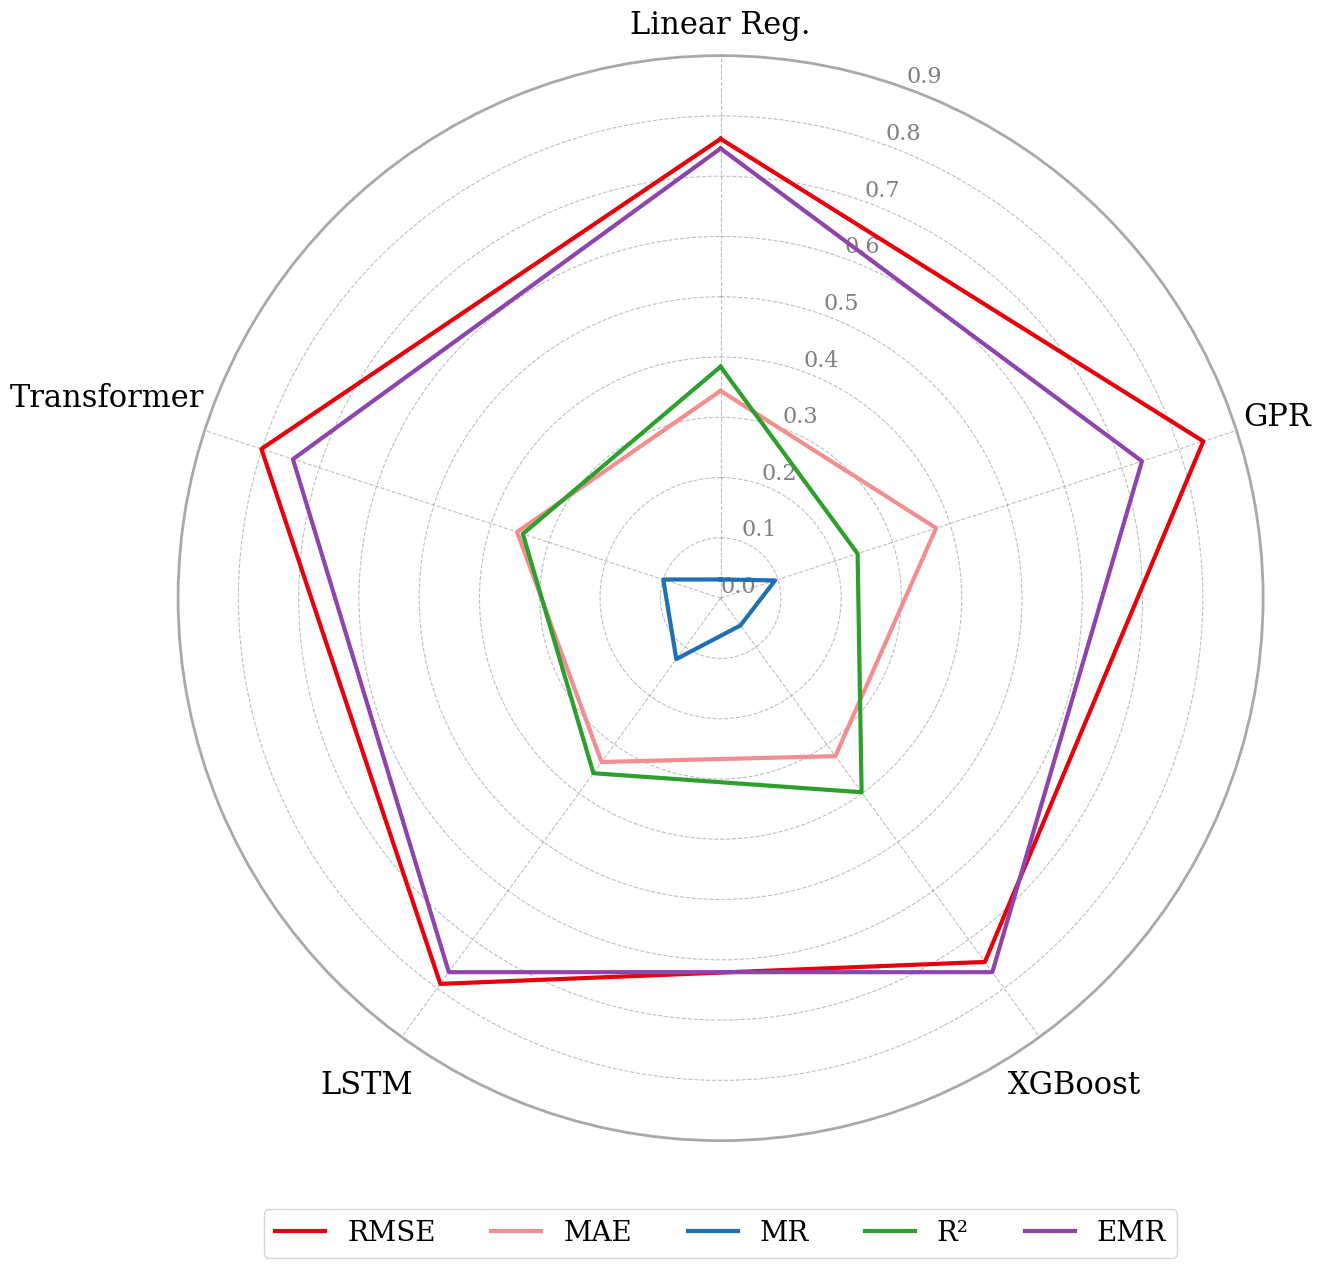

In [13]:
n_axes = len(avg_models)
angles = np.linspace(0, 2 * np.pi, n_axes, endpoint=False).tolist()
angles += angles[:1]  

fig, ax = plt.subplots(figsize=(14, 14), subplot_kw=dict(polar=True))

# Orientation: first axis at top, clockwise 
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

for metric in metric_plot_order:
    vals = avg_results[metric] + avg_results[metric][:1]  
    ax.plot(angles, vals, color=metric_styles[metric]["color"],
            linewidth=3, label=metric_styles[metric]["label"])

# Set tick positions but hide the default labels 
ax.set_xticks(angles[:-1])
ax.set_xticklabels([])

# Radial grid 0.0 -> 0.9
ax.set_ylim(0, 0.9)
ax.set_yticks(np.arange(0.0, 1.0, 0.1))
ax.set_yticklabels([f"{v:.1f}" for v in np.arange(0.0, 1.0, 0.1)],
                   fontsize=16, color="gray")
ax.set_rlabel_position(20)

ax.grid(color="gray", linestyle="--", alpha=0.5)

# outer circle boldness
OUTER_CIRCLE_WIDTH = 2.0      
OUTER_CIRCLE_COLOR = "darkgray"
ax.spines["polar"].set_color(OUTER_CIRCLE_COLOR)
ax.spines["polar"].set_linewidth(OUTER_CIRCLE_WIDTH)

# INDEPENDENT label padding per model
LABEL_RADIUS = {
    "Linear Reg.": 0.95,   
    "GPR":         0.97,  
    "XGBoost":     1.00,  
    "LSTM":        1.00,  
    "Transformer": 1.07,   
}

for ang, model in zip(angles[:-1], avg_models):
    ax.text(ang, LABEL_RADIUS[model], model,
            fontsize=22, ha="center", va="center")

# Legend below the plot, single row
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05),
          ncol=5, fontsize=20, frameon=True,
          handlelength=1.8, columnspacing=2.0)

plt.subplots_adjust(top=0.90, bottom=0.12)
plt.savefig(os.path.join(SAVE_DIR, "zone_average_result.png"),
            dpi=600, bbox_inches="tight")

In [13]:
# Regional prediction regeneration — setup
sys.path.append("3_utils")

from data_loader import load_regional_data
from preprocessing import (
    preprocess_lag_features,
    preprocess_sequences,
    preprocess_sequences_with_time,
)

BASE = "4_model_training_and_evaluation"

# Selected regional trial per model (correct extensions: .pkl / .json / .keras)
regional_selection = {
    "Linear Reg.": {"folder": "01_linear_regression", "model_type": "linear",      "trial": "trial_033.pkl"},
    "GPR":         {"folder": "02_gpr",               "model_type": "gpr",         "trial": "trial_061.pkl"},
    "XGBoost":     {"folder": "03_xgboost",           "model_type": "xgboost",     "trial": "trial_287.json"},
    "LSTM":        {"folder": "04_lstm",              "model_type": "lstm",        "trial": "trial_082.keras"},
    "Transformer": {"folder": "05_transformer",       "model_type": "transformer", "trial": "trial_175.keras"},
}

In [14]:
# %%
# Regional prediction regeneration — setup
sys.path.append("3_utils")

from data_loader import load_regional_data
from preprocessing import (
    preprocess_lag_features,
    preprocess_sequences,
    preprocess_sequences_with_time,
)

BASE = "4_model_training_and_evaluation"

# Selected regional trial per model 
regional_selection = {
    "Linear Reg.": {"folder": "01_linear_regression", "model_type": "linear",      "trial": "trial_033.pkl"},
    "GPR":         {"folder": "02_gpr",               "model_type": "gpr",         "trial": "trial_061.pkl"},
    "XGBoost":     {"folder": "03_xgboost",           "model_type": "xgboost",     "trial": "trial_287.json"},
    "LSTM":        {"folder": "04_lstm",              "model_type": "lstm",        "trial": "trial_082.keras"},
    "Transformer": {"folder": "05_transformer",       "model_type": "transformer", "trial": "trial_175.keras"},
}

In [15]:
# Regional prediction regeneration — helper functions
def eval_csv_path(folder, model_type):
    return os.path.join(BASE, folder, "regional_level_tuning",
                        "model_selection_results",
                        f"regional_{model_type}_top_models_test_eval.csv")

def get_params(row, model_type):
    if model_type == "linear":
        return {"fire_lag": int(row["fire_lag"]), "climate_lag": int(row["climate_lag"]),
                "fit_intercept": bool(row["fit_intercept"])}
    if model_type == "gpr":
        return {"fire_lag": int(row["fire_lag"]), "climate_lag": int(row["climate_lag"]),
                "constant_value": float(row["constant_value"]),
                "length_scale": float(row["length_scale"]), "alpha": float(row["alpha"])}
    if model_type == "xgboost":
        return {"fire_lag": int(row["fire_lag"]), "climate_lag": int(row["climate_lag"]),
                "n_estimators": int(row["n_estimators"]), "max_depth": int(row["max_depth"]),
                "learning_rate": float(row["learning_rate"]), "subsample": float(row["subsample"]),
                "colsample_bytree": float(row["colsample_bytree"]), "gamma": float(row["gamma"]),
                "reg_alpha": float(row["reg_alpha"]), "reg_lambda": float(row["reg_lambda"])}
    if model_type == "lstm":
        return {"lstm_units": int(row["lstm_units"]), "batch_size": int(row["batch_size"]),
                "dropout_rate": float(row["dropout_rate"]), "learning_rate": float(row["learning_rate"]),
                "lag_days": int(row["lag_days"]), "num_layers": int(row["num_layers"]),
                "sequence_length": int(row["sequence_length"]),
                "activation_function": str(row["activation_function"]), "optimizer": str(row["optimizer"])}
    if model_type == "transformer":
        return {"batch_size": int(row["batch_size"]), "learning_rate": float(row["learning_rate"]),
                "dropout_rate": float(row["dropout_rate"]), "lag_days": int(row["lag_days"]),
                "sequence_length": int(row["sequence_length"]), "d_model": int(row["d_model"]),
                "num_heads": int(row["num_heads"]), "ff_dim": int(row["ff_dim"]),
                "num_layers": int(row["num_layers"]), "month_embed_dim": int(row["month_embed_dim"]),
                "dow_embed_dim": int(row["dow_embed_dim"]), "optimizer": str(row["optimizer"])}

def predict_regional(model_type, model_path, params):
    df = load_regional_data()
    if model_type in ("linear", "gpr", "xgboost"):
        pre = preprocess_lag_features(df.copy(), params)
        _, _, _, _, X_test, y_test, df_test = pre
        if model_type == "xgboost":
            model = XGBRegressor(); model.load_model(model_path)
            y_pred_raw = model.predict(X_test)
        elif model_type == "gpr":
            model = joblib.load(model_path)
            y_pred_raw, _ = model.predict(X_test, return_std=True)
        else:
            model = joblib.load(model_path)
            y_pred_raw = model.predict(X_test)
        y_pred = np.round(np.clip(y_pred_raw, 0, None))
        y_true = np.round(np.clip(y_test, 0, None))
        dates = df_test["Date"].reset_index(drop=True)

    elif model_type == "lstm":
        pre = preprocess_sequences(df.copy(), params)
        _, _, _, _, X_test, y_test, df_test, scaler_y = pre
        model = load_model(model_path, custom_objects={"mse": MeanSquaredError()})
        y_pred = np.round(np.clip(scaler_y.inverse_transform(model.predict(X_test)).flatten(), 0, None))
        y_true = np.round(np.clip(scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten(), 0, None))
        dates = df_test["Date"].reset_index(drop=True)

    elif model_type == "transformer":
        pre = preprocess_sequences_with_time(df.copy(), params)
        _, _, _, _, _, _, _, _, X_test, y_test, month_test, dow_test, df_test, scaler_y = pre
        model = load_model(model_path, custom_objects={"mse": MeanSquaredError()})
        y_pred = np.round(np.clip(scaler_y.inverse_transform(model.predict([X_test, month_test, dow_test])).flatten(), 0, None))
        y_true = np.round(np.clip(scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten(), 0, None))
        dates = df_test["Date"].reset_index(drop=True)

    return pd.DataFrame({"Date": pd.to_datetime(dates),
                         "y_true": np.asarray(y_true).flatten(),
                         "y_pred": np.asarray(y_pred).flatten()})

In [16]:
# Regional prediction regeneration — run for all 5 models
regional_preds = {}
for model_name, cfg in regional_selection.items():
    csv = eval_csv_path(cfg["folder"], cfg["model_type"])
    dfe = pd.read_csv(csv)
    row = dfe[dfe["model_filename"] == cfg["trial"]]
    if row.empty:
        print(f"{model_name}: {cfg['trial']} NOT FOUND in {csv}")
        continue
    row = row.iloc[0]
    params = get_params(row, cfg["model_type"])
    regional_preds[model_name] = predict_regional(cfg["model_type"], row["model_path"], params)
    print(f"{model_name}: {len(regional_preds[model_name])} rows")

Linear Reg.: 487 rows
GPR: 487 rows
XGBoost: 487 rows


I0000 00:00:1785587348.659064  127193 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 11525 MB memory:  -> device: 0, name: NVIDIA TITAN Xp, pci bus id: 0000:02:00.0, compute capability: 6.1
I0000 00:00:1785587348.659752  127193 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 11532 MB memory:  -> device: 1, name: NVIDIA TITAN Xp, pci bus id: 0000:81:00.0, compute capability: 6.1


 1/15 ━━━━━━━━━━━━━━━━━━━━ 9s 693ms/step

I0000 00:00:1785587356.072769  129763 cuda_dnn.cc:461] Loaded cuDNN version 90800


15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
LSTM: 479 rows


I0000 00:00:1785587357.515515  129763 service.cc:153] XLA service 0x795e364085b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1785587357.515550  129763 service.cc:161]   StreamExecutor [0]: NVIDIA TITAN Xp, Compute Capability 6.1 (Driver: 12.8.0; Runtime: 12.8.0; Toolkit: 12.5.0; DNN: 9.8.0)
I0000 00:00:1785587357.515562  129763 service.cc:161]   StreamExecutor [1]: NVIDIA TITAN Xp, Compute Capability 6.1 (Driver: 12.8.0; Runtime: 12.8.0; Toolkit: 12.5.0; DNN: 9.8.0)
I0000 00:00:1785587358.230453  129763 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1785587359.001117  129763 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1878__.15


 1/15 ━━━━━━━━━━━━━━━━━━━━ 50s 4s/step

I0000 00:00:1785587360.800031  129763 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
I0000 00:00:1785587361.429811  129761 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2308__.15


15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 154ms/step
Transformer: 469 rows


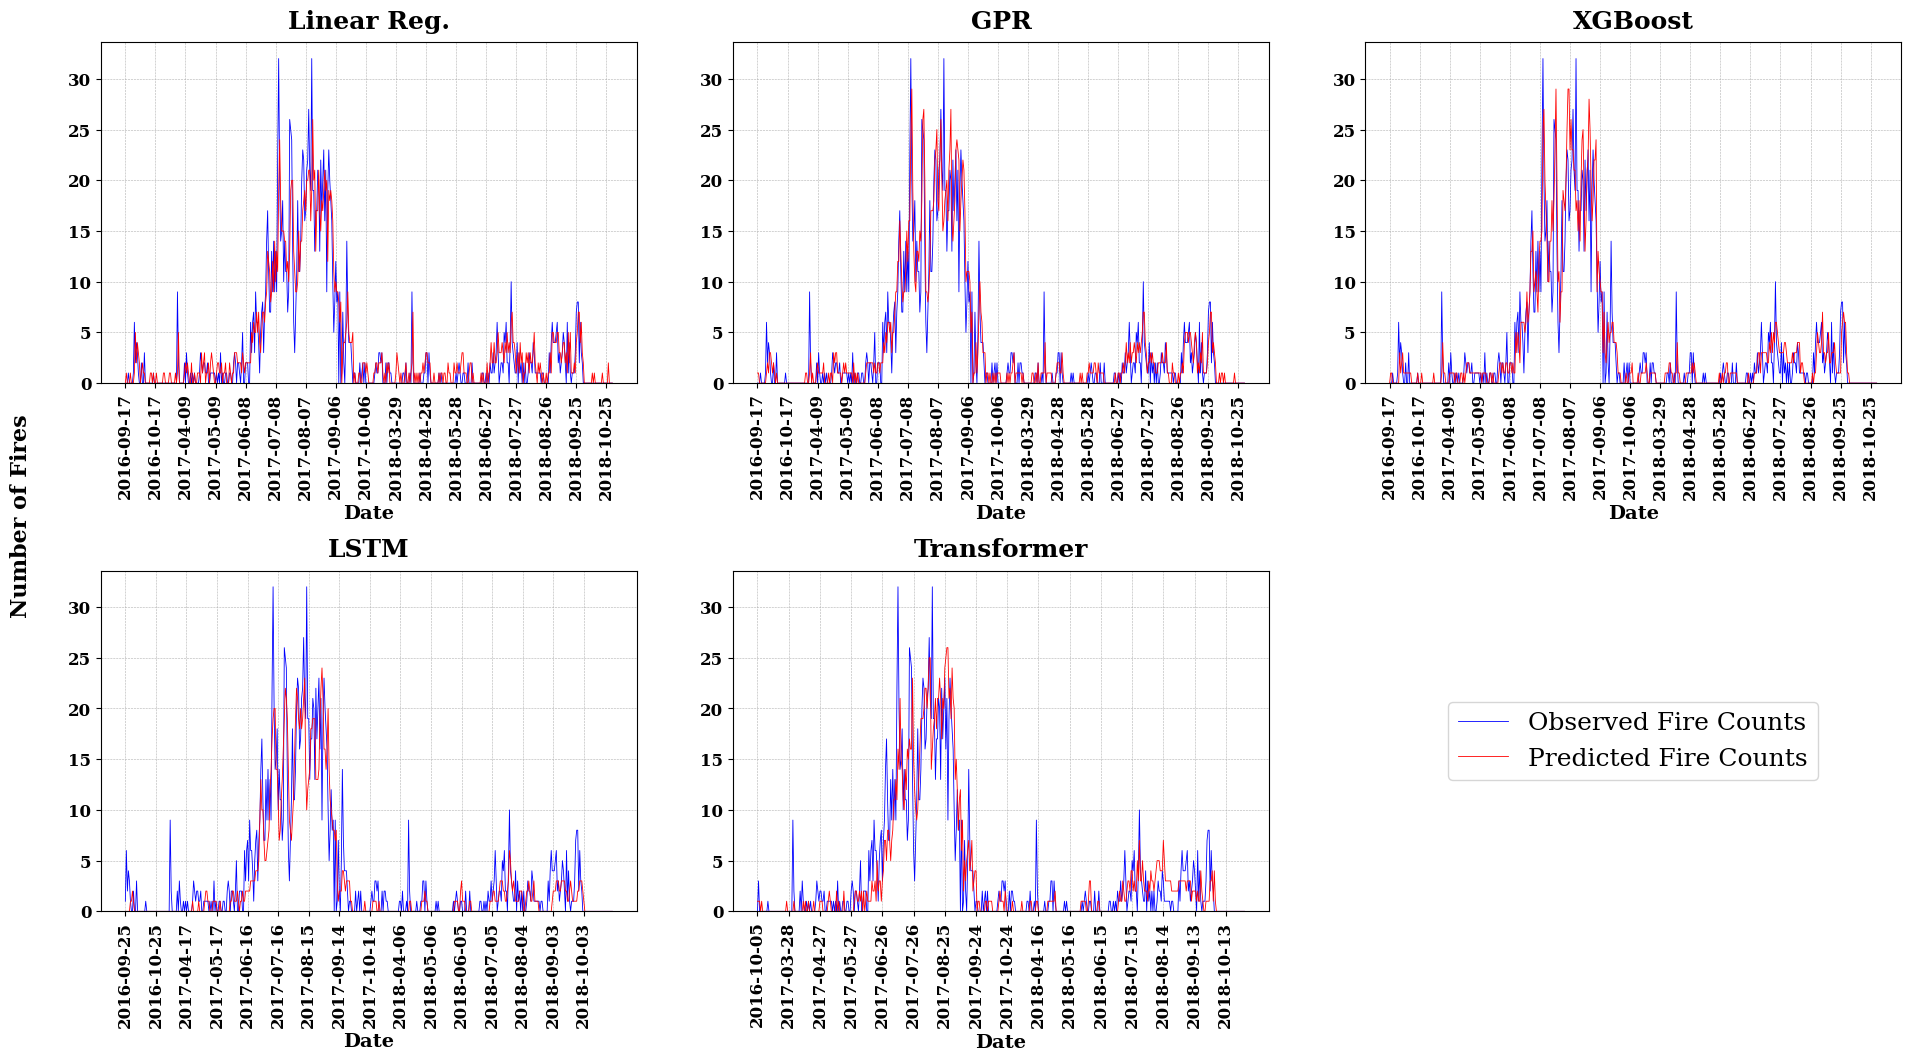

Saved: plots/results/regional_obs_pre.png


In [19]:
# Regional observed vs predicted: 5 panels (2x3), shared legend in 6th slot
import matplotlib.ticker as ticker

plot_models = ["Linear Reg.", "GPR", "XGBoost", "LSTM", "Transformer"]
tick_step = 30          
y_interval = 5         

fig, axes = plt.subplots(2, 3, figsize=(20, 11))
axes = axes.flatten()

for i, model_name in enumerate(plot_models):
    ax = axes[i]
    df = regional_preds.get(model_name)
    if df is None:
        ax.set_visible(False); continue

    n = len(df); x = np.arange(n)
    date_labels = df["Date"].dt.strftime("%Y-%m-%d").values
    xticks = np.arange(0, n, tick_step)

    ax.plot(x, df["y_true"].values, label="Observed Fire Counts", color="blue", linewidth=0.6)
    ax.plot(x, df["y_pred"].values, label="Predicted Fire Counts", color="red", linewidth=0.6)

    ax.set_title(model_name, fontsize=18, fontweight="bold", pad=10)
    ax.set_xticks(xticks)
    ax.set_xticklabels(date_labels[xticks], rotation=90, fontsize=12, fontweight="bold")
    ax.tick_params(axis="y", labelsize=12)
    for label in ax.get_yticklabels():
        label.set_fontweight("bold")
    ax.yaxis.set_major_locator(ticker.MultipleLocator(y_interval))
    ax.set_ylim(bottom=0)
    ax.grid(True, linestyle="--", linewidth=0.4)
    ax.set_xlabel("Date", fontsize=14, fontweight="bold")

# Shared legend in the empty 6th panel
axes[5].axis("off")
handles, labels = axes[0].get_legend_handles_labels()
axes[5].legend(handles, labels, loc="center", fontsize=18, frameon=True, handlelength=2.0)

# Shared y-label
fig.text(0.04, 0.5, "Number of Fires", ha="center", va="center",
         rotation="vertical", fontsize=16, fontweight="bold")

plt.subplots_adjust(left=0.08, bottom=0.14, right=0.98, top=0.93, wspace=0.18, hspace=0.55)
plot_path = os.path.join(SAVE_DIR, "regional_obs_pre.png")
plt.savefig(plot_path, dpi=600, bbox_inches="tight")
plt.show()
print(f"Saved: {plot_path}")